In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the File Path
file_path = '/content/drive/MyDrive/Crop and fertilizer dataset.csv'

# Load the CSV File using Pandas
import pandas as pd

# Load the dataset from Google Drive
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(data.head())

# Display information about the dataset
print("\nDataset information (column names, data types, and missing values):")
print(data.info())

Mounted at /content/drive
First few rows of the dataset:
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000   
2      Kolhapur      Black        85          50        100  6.5      1000   
3      Kolhapur      Black        90          50        100  6.5      1000   
4      Kolhapur      Black        95          50        100  6.5      1000   

   Temperature       Crop Fertilizer                          Link  
0           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
1           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
2           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
3           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
4           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  

Dataset information (column names, data types, and missing 

In [2]:
# Check the columns and data types
print(data.info())

# Check for null values
print(data.isnull().sum())

# Summary statistics for numerical columns
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  4513 non-null   object 
 1   Soil_color     4513 non-null   object 
 2   Nitrogen       4513 non-null   int64  
 3   Phosphorus     4513 non-null   int64  
 4   Potassium      4513 non-null   int64  
 5   pH             4513 non-null   float64
 6   Rainfall       4513 non-null   int64  
 7   Temperature    4513 non-null   int64  
 8   Crop           4513 non-null   object 
 9   Fertilizer     4513 non-null   object 
 10  Link           4513 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 388.0+ KB
None
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64
          Nitrogen   Phosphoru

In [3]:
# Keep only relevant columns
relevant_columns = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
filtered_data = data[relevant_columns]
print(filtered_data.head())

   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


In [4]:
# Handle missing values

# Handle missing values (NaN) using imputation
# Fill with the mean (suitable for numerical data)
for col in ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']:
    filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())

# Fill with a specific value (e.g., 0)
filtered_data.fillna(0, inplace=True)

# Drop rows with missing values (if the number of missing values is small)
filtered_data.dropna(inplace=True)


# Verify if there are still missing values after handling
print(filtered_data.isnull().sum())

print(filtered_data.head())

Nitrogen       0
Phosphorus     0
Potassium      0
pH             0
Rainfall       0
Temperature    0
dtype: int64
   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


<ipython-input-4-7647b315d2b7>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())
<ipython-input-4-7647b315d2b7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.fillna(0, inplace=True)
<ipython-input-4-7647b315d2b7>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.dropna(inplace=

In [5]:
# Remove duplicate rows based on all columns
filtered_data = filtered_data.drop_duplicates()

# Display the DataFrame after removing duplicates
print(filtered_data.head())
filtered_data.shape

   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


(4436, 6)

In [6]:
# Handle Outliers using IQR

import pandas as pd

# Assuming 'filtered_data' DataFrame from the previous code

def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Apply the function to each relevant column
for col in ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']:
    filtered_data = handle_outliers_iqr(filtered_data, col)

print(filtered_data.shape)
print(filtered_data.head())

(3797, 6)
   Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature
0        75          50        100  6.5      1000           20
1        80          50        100  6.5      1000           20
2        85          50        100  6.5      1000           20
3        90          50        100  6.5      1000           20
4        95          50        100  6.5      1000           20


In [7]:
# Normalize Numerical Features
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Select numerical features to scale
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']

# Fit and transform the numerical features
filtered_data[numerical_features] = scaler.fit_transform(filtered_data[numerical_features])

# Display the first few rows of the scaled data
print(filtered_data.head())

   Nitrogen  Phosphorus  Potassium        pH  Rainfall  Temperature
0  0.423077         0.5   0.791667  0.333333       0.7     0.333333
1  0.461538         0.5   0.791667  0.333333       0.7     0.333333
2  0.500000         0.5   0.791667  0.333333       0.7     0.333333
3  0.538462         0.5   0.791667  0.333333       0.7     0.333333
4  0.576923         0.5   0.791667  0.333333       0.7     0.333333


In [8]:
# Split data into inputs (X) and outputs (y)
# Inputs: Environmental and soil conditions
X = filtered_data[['pH', 'Rainfall', 'Temperature', 'Nitrogen', 'Phosphorus', 'Potassium']]

# Outputs: Target fertilizer recommendations (amount of NPK to be added)
y = filtered_data[['Nitrogen', 'Phosphorus', 'Potassium']]


In [9]:
# Apply Random Forest Regressor to compute feature importance

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Print feature importances
for i, feature_name in enumerate(X.columns):
    print(f"Feature Importance of {feature_name}: {feature_importances[i]}")

Feature Importance of pH: 0.0009475121034771711
Feature Importance of Rainfall: 0.0007609533291264816
Feature Importance of Temperature: 0.0007003225484683873
Feature Importance of Nitrogen: 0.6506901784525138
Feature Importance of Phosphorus: 0.12021771062322784
Feature Importance of Potassium: 0.22668332294318636


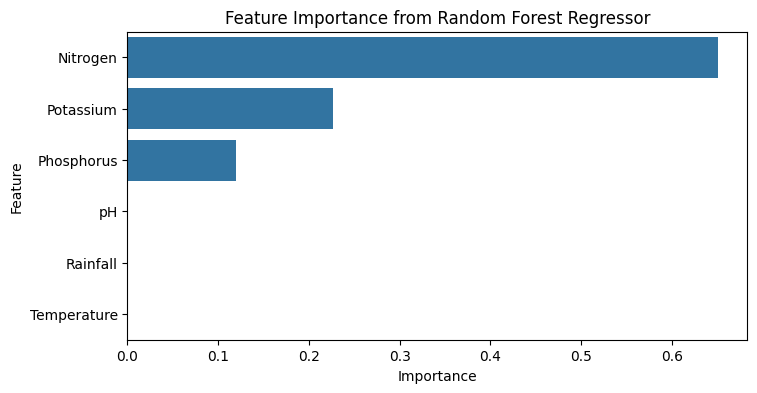

In [10]:
# Visualize feature importance

import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [11]:
# Dimensionality Reduction with PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce features while maintaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Number of components selected by PCA: {pca.n_components_}")


Number of components selected by PCA: 6


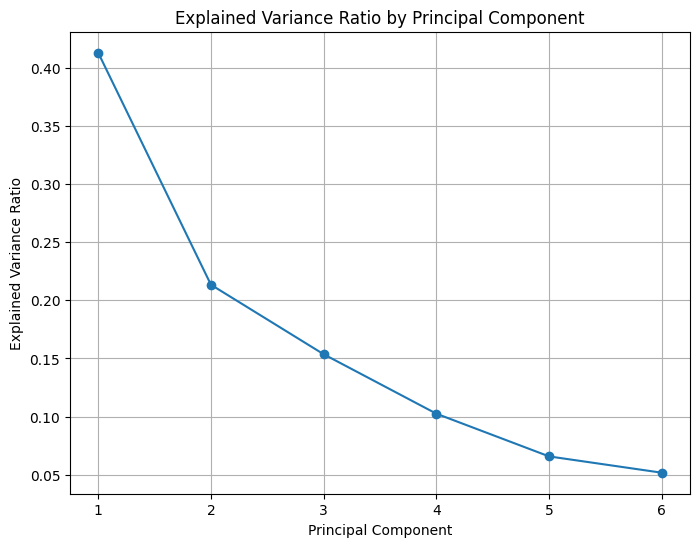

In [12]:

# Visualize explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.grid(True)
plt.show()

In [13]:
# Decision Tree Feature Selection
from sklearn.tree import DecisionTreeRegressor

# Create and fit the Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Feature importance from Decision Tree
dt_feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Decision Tree Feature Importances:\n", dt_feature_importances)

Decision Tree Feature Importances:
        Feature  Importance
3     Nitrogen    0.656057
5    Potassium    0.222942
4   Phosphorus    0.119242
0           pH    0.000811
2  Temperature    0.000681
1     Rainfall    0.000266


In [14]:
# Regression Feature Contribution
from sklearn.linear_model import LinearRegression

# Create and fit the Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Coefficients from Regression
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Regression Coefficients:\n", coefficients)

Regression Coefficients:
        Feature   Coefficient
3     Nitrogen  1.000000e+00
2  Temperature  6.314393e-16
5    Potassium  1.110223e-16
4   Phosphorus -5.551115e-17
1     Rainfall -1.110223e-16
0           pH -5.119967e-16


In [15]:
# Combine Results to Finalize Features

# Combine Feature Importance Scores

# Create a dictionary to store feature importance from different methods
feature_importance_dict = {}

# Add Random Forest feature importance
for i, feature_name in enumerate(X.columns):
    feature_importance_dict[feature_name] = feature_importance_dict.get(feature_name, 0) + feature_importances[i]

# Add Decision Tree feature importance
for index, row in dt_feature_importances.iterrows():
    feature_importance_dict[row['Feature']] = feature_importance_dict.get(row['Feature'], 0) + row['Importance']

# Add Linear Regression coefficients (magnitude as importance)
for index, row in coefficients.iterrows():
    feature_importance_dict[row['Feature']] = feature_importance_dict.get(row['Feature'], 0) + abs(row['Coefficient'])


# Convert the dictionary to a DataFrame
combined_importance_df = pd.DataFrame.from_dict(feature_importance_dict, orient='index', columns=['Combined Importance'])

# Sort by combined importance
combined_importance_df = combined_importance_df.sort_values(by='Combined Importance', ascending=False)

# Display the combined feature importance
print("\nCombined Feature Importance:\n", combined_importance_df)


# Final Feature Selection (example: top 3 features)
top_n_features = 3
selected_features = combined_importance_df.index[:top_n_features].tolist()

print("\nSelected Features:", selected_features)

# Re-train your model using only the selected features
X_selected = X[selected_features]
X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Example: Re-train with RandomForestRegressor
rf_model_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_model_selected.predict(X_test_selected)

# Evaluate the model (example: Mean Squared Error)
mse_selected = mean_squared_error(y_test, y_pred_selected)
print(f"Mean Squared Error with selected features: {mse_selected}")


Combined Feature Importance:
              Combined Importance
Nitrogen                2.306747
Potassium               0.449625
Phosphorus              0.239460
pH                      0.001758
Temperature             0.001382
Rainfall                0.001027

Selected Features: ['Nitrogen', 'Potassium', 'Phosphorus']
Mean Squared Error with selected features: 8.420885934364025e-05


In [ ]:
# Save the final dataset (filtered_data) to Google Drive
final_dataset_path = '/content/drive/MyDrive/Final_fertilizer_dataset.csv'
filtered_data.to_csv(final_dataset_path, index=False)